IMPORTING LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

LOADING DATA AND CHECKING THE DATA STRUCTURE

In [3]:
df = pd.read_csv("Housing.csv")
print("Shape:", df.shape)
print(df.info())
df.head(10)

Shape: (545, 13)
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB
None


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
# Setting the index name to house index
df.index.name = 'house_id'
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
house_id,,,,,,,,,,,,,
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished


In [5]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

Converting Neccessary Columns

In [7]:
# Convert yes/no columns to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
               'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].replace({'yes': 1, 'no': 0})

# Convert furnishingstatus
df['furnishingstatus'] = df['furnishingstatus'].replace({
    'furnished': 2, 
    'semi-furnished': 1, 
    'unfurnished': 0
})

In [ ]:
# Convert the binary cols to int
for col in binary_cols:
    df[col] = df[col].replace({'yes': 1, 'no': 0}).astype(int)

df['furnishingstatus'] = df['furnishingstatus'].replace({
    'furnished': 2, 
    'semi-furnished': 1, 
    'unfurnished': 0
}).astype(int)

In [10]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad            int64
guestroom           int64
basement            int64
hotwaterheating     int64
airconditioning     int64
parking             int64
prefarea            int64
furnishingstatus    int64
dtype: object

In [12]:
df.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,0.930275
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.761373
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,2.000000


EDA

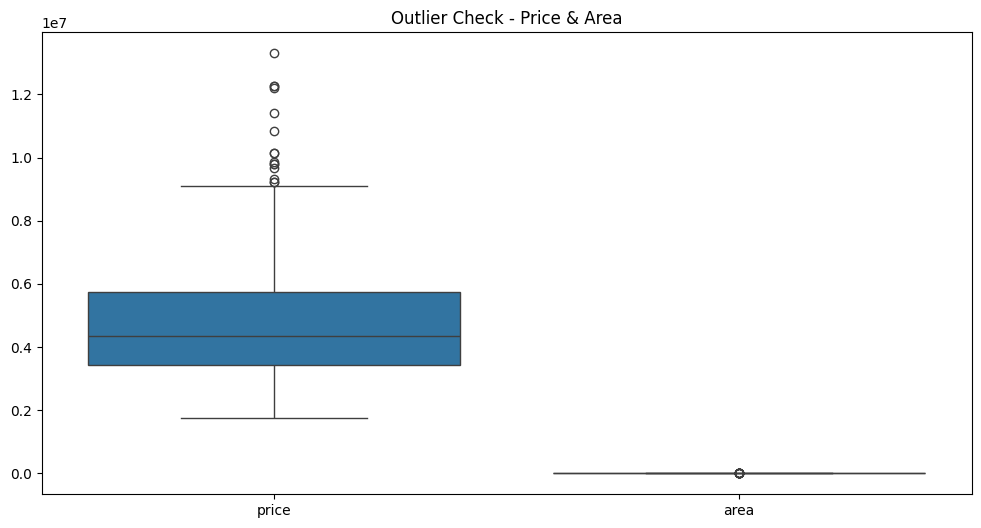

In [13]:
# Using a box plot to check for outlier
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['price', 'area']])
plt.title('Outlier Check - Price & Area')
plt.show()

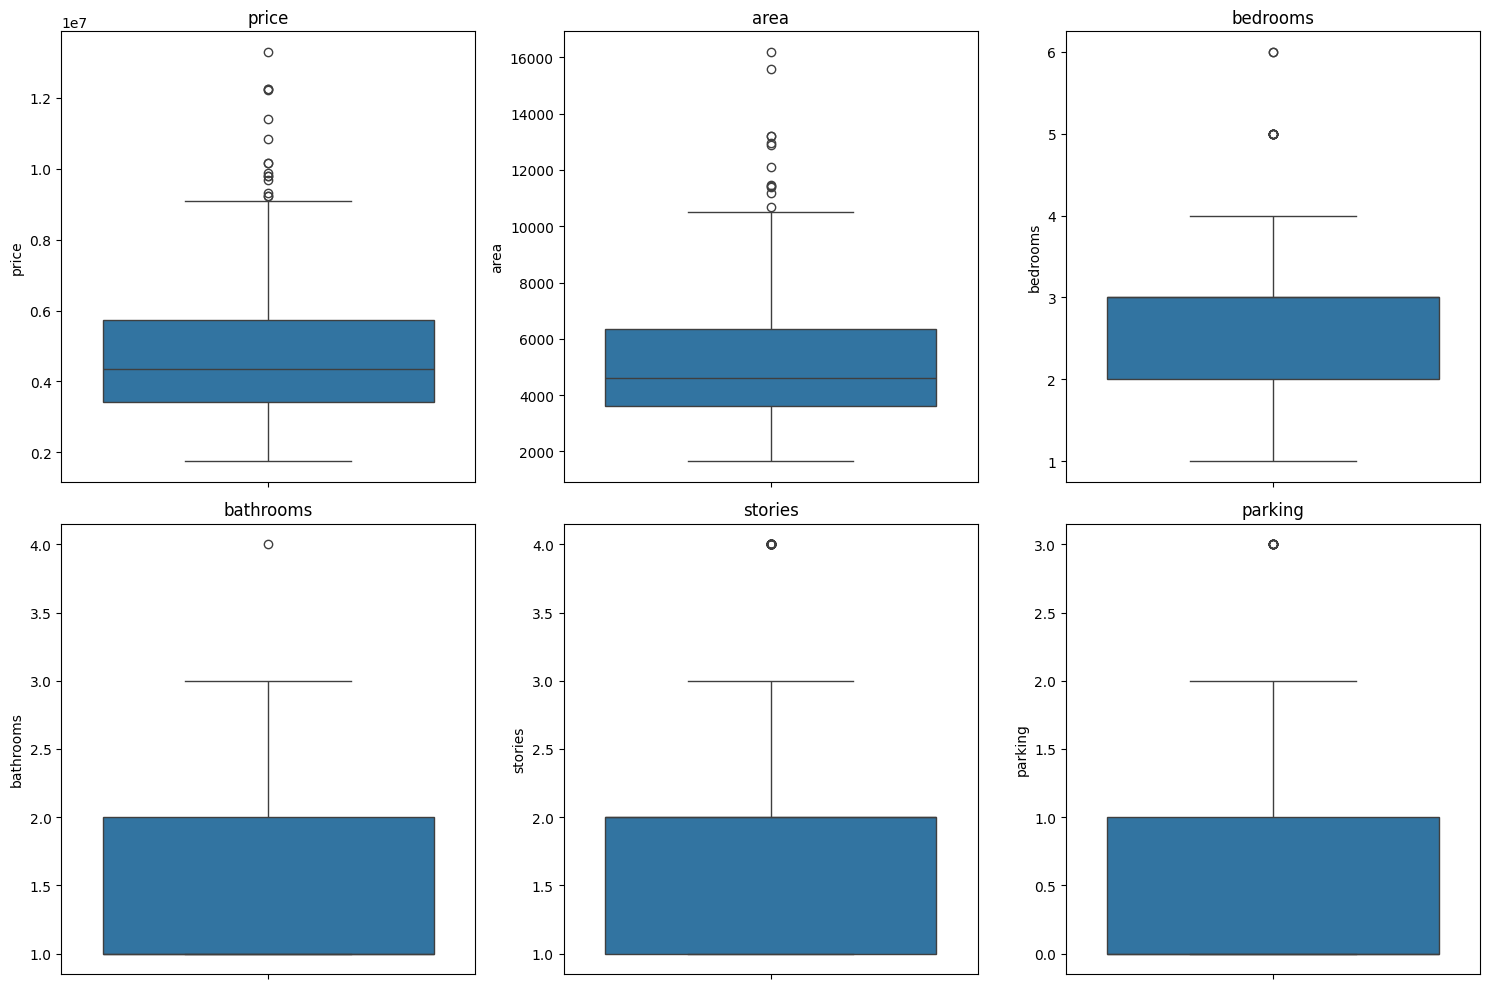

In [14]:
# Checking all the numeric colums at once
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i//3][i%3])
    axes[i//3][i%3].set_title(col)

plt.tight_layout()
plt.show()

Since there are no outliers then the data is clean.

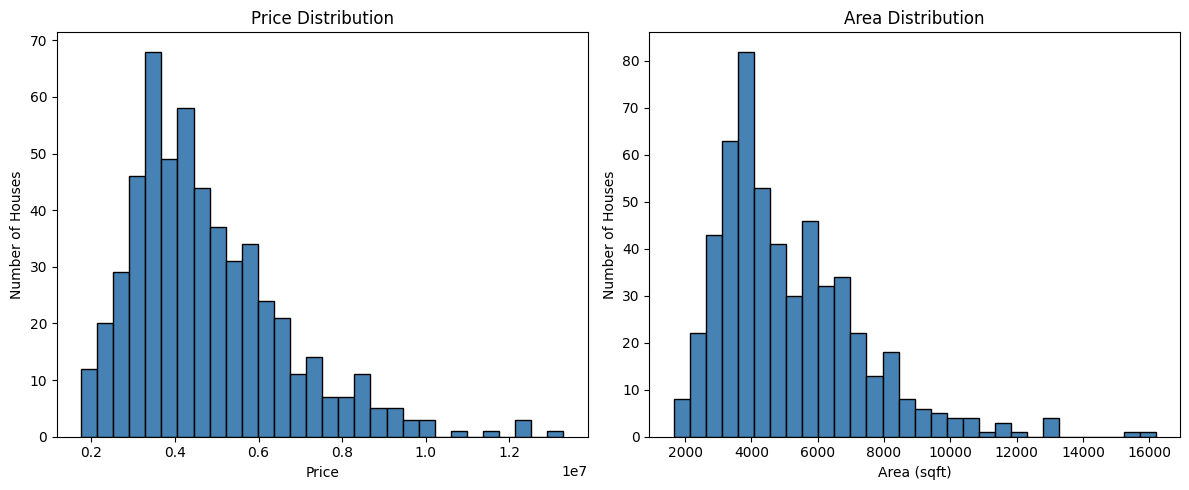

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Price histogram
axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Number of Houses')

# Area histogram
axes[1].hist(df['area'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Area Distribution')
axes[1].set_xlabel('Area (sqft)')
axes[1].set_ylabel('Number of Houses')

plt.tight_layout()
plt.show()

From the distribution above I can see that there are no outliers. The distribution from the histogram is right skewed. Most houses are affordable/mid-range, with a small number of luxury properties pulling the average up. Most houses are medium-sized, with a few unusually large properties.

In [18]:
df.to_csv("Housing_clean.csv")

In [19]:
df.var().sort_values(ascending=False)

price               3.498544e+12
area                4.709512e+06
stories             7.525432e-01
parking             7.423300e-01
furnishingstatus    5.796883e-01
bedrooms            5.447383e-01
bathrooms           2.524757e-01
basement            2.280559e-01
airconditioning     2.163923e-01
prefarea            1.800324e-01
guestroom           1.465731e-01
mainroad            1.215461e-01
hotwaterheating     4.384781e-02
dtype: float64

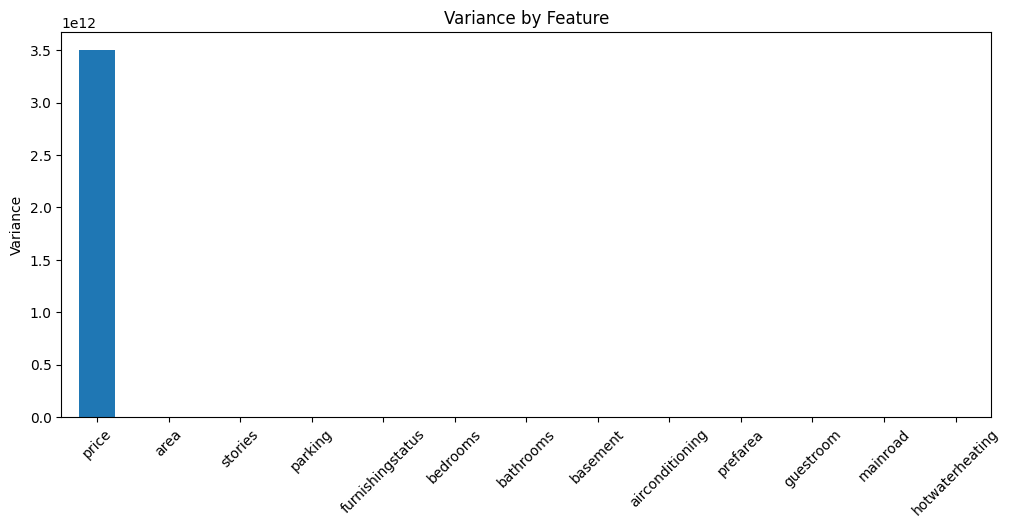

In [20]:
df.var().sort_values(ascending=False).plot(kind='bar', figsize=(12, 5))
plt.title('Variance by Feature')
plt.ylabel('Variance')
plt.xticks(rotation=45)
plt.show()

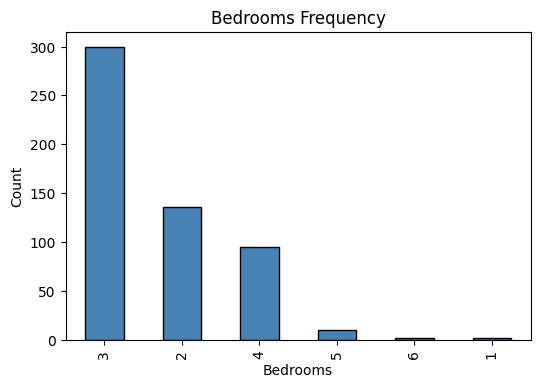

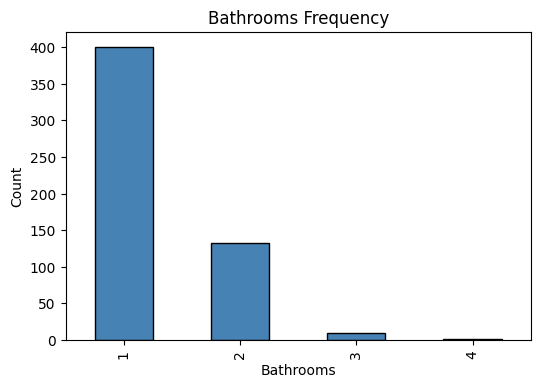

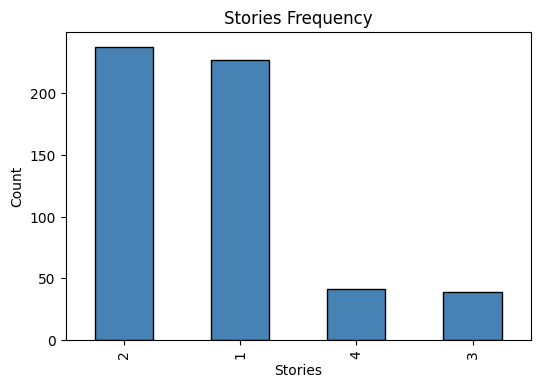

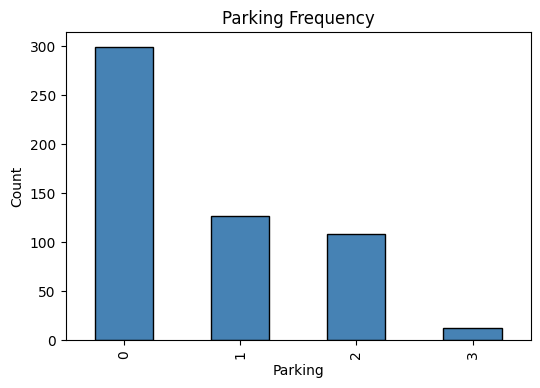

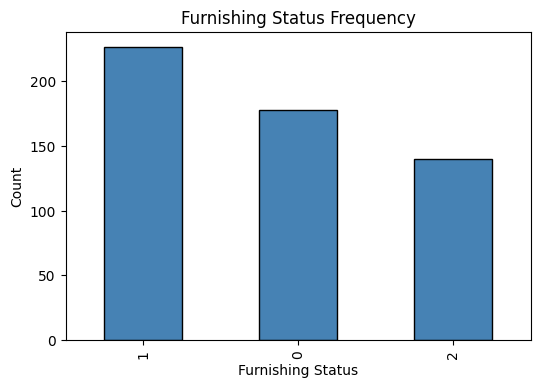

In [21]:
# Bedrooms
plt.figure(figsize=(6, 4))
df['bedrooms'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Bedrooms Frequency')
plt.xlabel('Bedrooms')
plt.ylabel('Count')
plt.show()

# Bathrooms
plt.figure(figsize=(6, 4))
df['bathrooms'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Bathrooms Frequency')
plt.xlabel('Bathrooms')
plt.ylabel('Count')
plt.show()

# Stories
plt.figure(figsize=(6, 4))
df['stories'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Stories Frequency')
plt.xlabel('Stories')
plt.ylabel('Count')
plt.show()

# Parking
plt.figure(figsize=(6, 4))
df['parking'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Parking Frequency')
plt.xlabel('Parking')
plt.ylabel('Count')
plt.show()

# Furnishing Status
plt.figure(figsize=(6, 4))
df['furnishingstatus'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Furnishing Status Frequency')
plt.xlabel('Furnishing Status')
plt.ylabel('Count')
plt.show()

From the bar charts above. I can see that price is the feature with the highest variation and bedroom is the one that occur most frequently

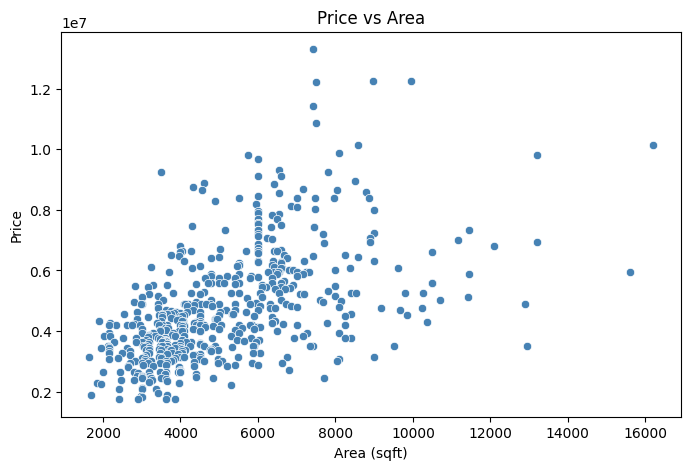

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='area', y='price', data=df, color='steelblue')
plt.title('Price vs Area')
plt.xlabel('Area (sqft)')
plt.ylabel('Price')
plt.show()

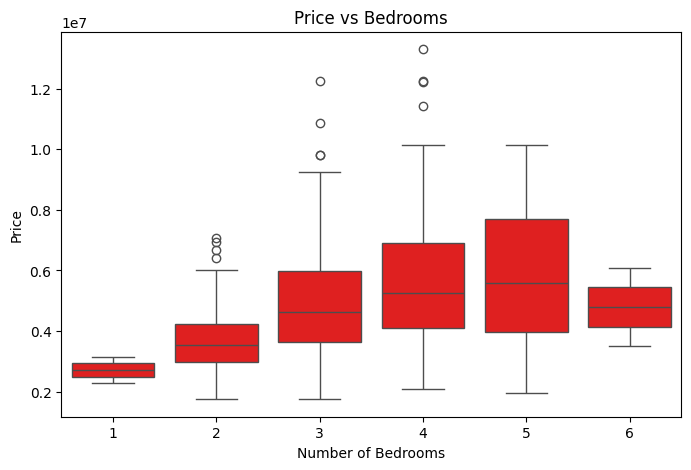

In [34]:
# Boxplot on price vs bedroom
plt.figure(figsize=(8, 5))
sns.boxplot(x='bedrooms', y='price', data=df, color='red')
plt.title('Price vs Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.show()

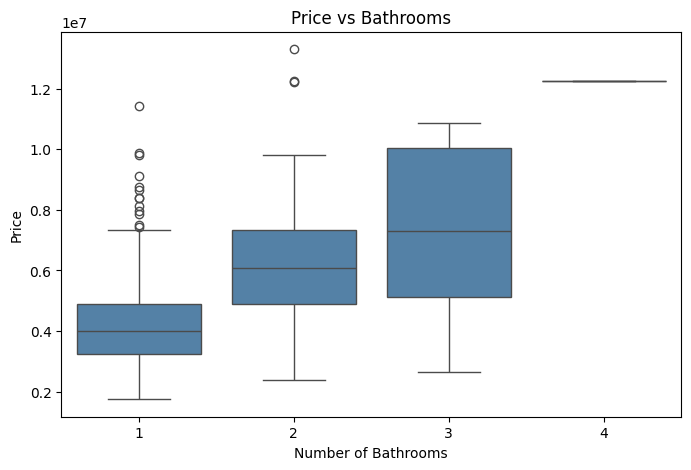

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='bathrooms', y='price', data=df, color='steelblue')
plt.title('Price vs Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price')
plt.show()

In [27]:
# Generate correlation matrix
corr_matrix = df.corr()
corr_matrix

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,0.304721
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,0.171445
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,0.123244
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,0.143559
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,0.104672
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,0.156726
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,0.118328
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,0.112831
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,0.031628
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,0.150477


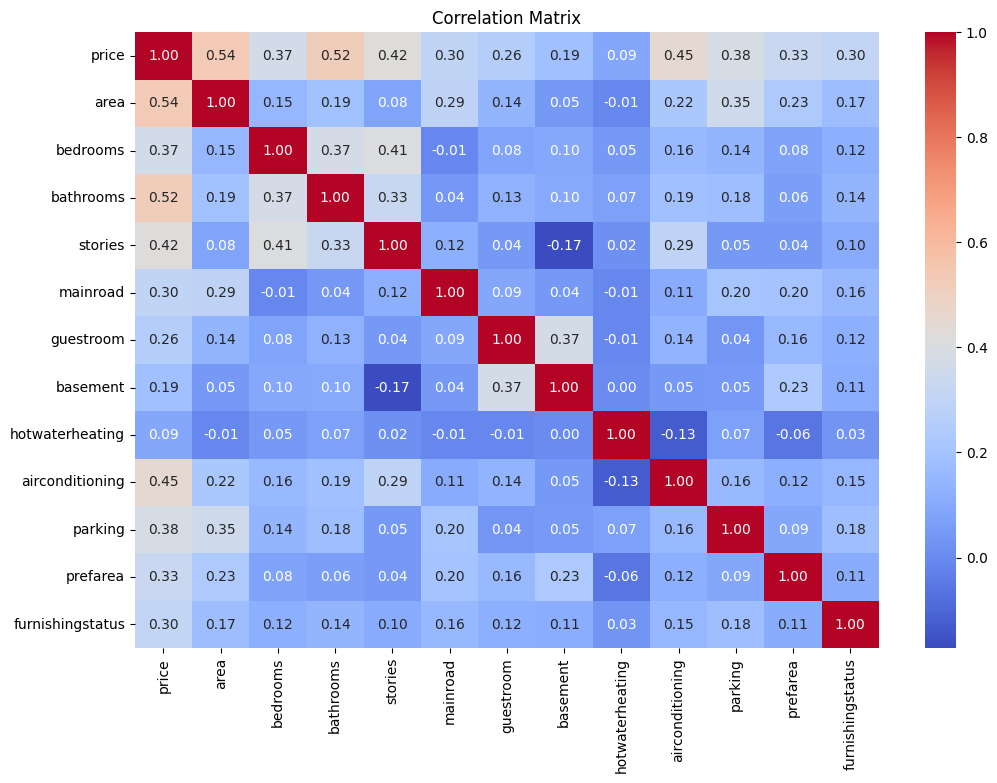

In [25]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

REDUNDANT FEATURES

Based on the correlation matrix, these features have very weak correlation with price:

Hotwaterheating: 0.09 correlation and it has almost no influence in predicting the price
Basement: 0.19 correlation and it has very weak influence.
Guestroom: 0.26 correlation and it has weak influence.

MOST IMPORTANT FEATURES

1. Area (0.54)
The physical size of the house is the single strongest predictor — buyers pay more for more space.
2. Bathrooms (0.52)
More bathrooms signals a larger, more luxurious home — second strongest predictor.
3. Airconditioning (0.45)
Houses with AC command a significant price premium — likely signals overall quality of the property.
4. Stories (0.42)
More floors means more living space — directly drives up price.
5. Parking (0.38)
Availability of parking adds measurable value to a property.
6. Bedrooms (0.37)
More bedrooms increases price but slightly less than bathrooms — interesting finding.

5 KEY INSIGHTS

Insight 1 — Area and Bathrooms dominate price
These two features alone have correlations above 0.50, making them the most reliable predictors of house price in this dataset.

Insight 2 — Airconditioning is surprisingly powerful
With a 0.45 correlation, airconditioning influences price more than bedrooms — suggesting it's a luxury marker buyers value highly.

Insight 3 — Most houses are mid-range priced
From the histogram, 70% of houses are priced between 2M—6M with a right skew — meaning a small number of luxury houses pull the average up significantly.

Insight 4 — Hotwaterheating is almost useless as a predictor

With only 0.09 correlation with price, hotwaterheating adds virtually no predictive value and should be dropped from the model.

Insight 5 — More bathrooms beats more bedrooms
Bathrooms (0.52) correlate more strongly with price than bedrooms (0.37) — meaning buyers value bathroom count more than bedroom count when determining price.